In [1]:
import pandas as pd
from sklearn.datasets import load_iris # Import the load_iris function from the sklearn.datasets module to load the iris dataset


In [2]:
# creating an object Iris which contains the iris dataset, picked from the sklearn library. The load_iris() function loads the iris dataset and returns it as a dictionary-like object with various attributes, including the data and target arrays.
iris = load_iris()
# print(iris.keys())
# print(iris.data.shape) # Print the shape of the data, which is a 2D array with rows representing samples and columns representing features
# print(iris.target.shape) # Print the shape of the target, which is a 1D array with rows representing samples
# print(iris.target)
# print(iris.data)

df = pd.DataFrame(iris.data, columns=iris.feature_names) # Create a DataFrame from the iris dataset, columns are named after the feature names in the dataset

In [3]:
# Checking my loaded dataset to see how it looks like, incase tere are any missing values, and to get a statistical summary of the dataset.
df.info()
print("="*100)
print(df.describe())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000      

(150, 4)

In [4]:
# Getting a quick snapshot of the dataset. 
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df["species"] = iris.target # Add a new column to the DataFrame called "species" which contains the target variable from the iris dataset
print(df["species"].unique()) #I want to see the unique values in the species column, found the names had been decoded into numbers. 

[0 1 2]


In [6]:
print(df["species"].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [7]:
# Data Preprocessing
from sklearn.model_selection import train_test_split #from the sklearn library (model_selection module), import the train_test_split function to split the dataset into training and testing sets.
from sklearn.preprocessing import StandardScaler #from the sklearn library (preprocessing module), import the StandardScaler class to standardize the features by removing the mean and scaling to unit variance.

X = iris.data #For purposes of training and test data splitting, x will represent the features (the statistical measurements of the iris flowers) and
y = iris.target # y will represent the target variable (the species of the iris flowers)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets using the train_test_split function. #
#The test_size parameter specifies the proportion of the dataset to include in the test split (20% in this case), 
# and random_state is set to 42 to ensure reproducibility of the results.

scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) # Fit the StandardScaler to the training data and transform it. 
#This will standardize the features in the training set by removing the mean and scaling to unit variance.
X_test = scaler.transform(X_test)  # use the SAME scaler, don't refit on test!

In [8]:
# Model Training
from sklearn.linear_model import LogisticRegression # Import the Logistic Regression model from scikit-learn
from sklearn.neighbors import KNeighborsClassifier # Import the K-Nearest Neighbors classifier from scikit-learn

lr = LogisticRegression(max_iter=200) # Create an instance of the Logistic Regression model with a maximum of 200 iterations (to ensure convergence)
lr.fit(X_train, y_train) # Fit the Logistic Regression model to the training data (X_train and y_train) 

knn = KNeighborsClassifier(n_neighbors=5) # Create an instance of the K-Nearest Neighbors classifier with 5 neighbors (k=5)
knn.fit(X_train, y_train) # Fit the K-Nearest Neighbors classifier to the training data (X_train and y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None



--- Logistic Regression ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



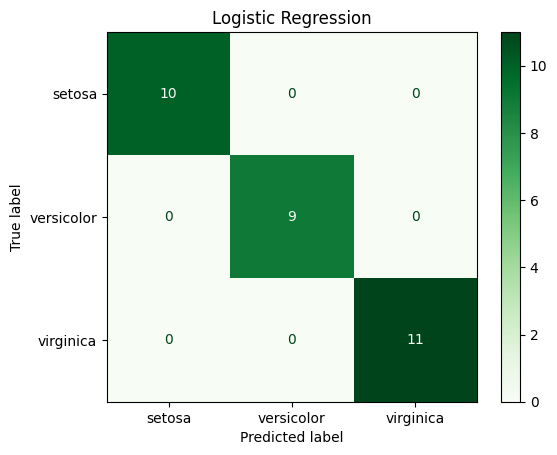


--- KNN ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



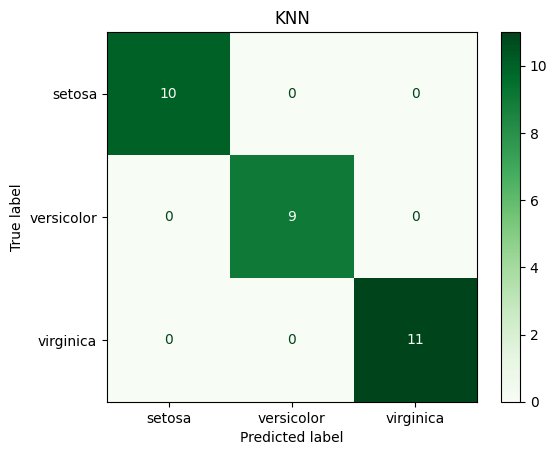

In [11]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # Import the classification_report, confusion_matrix, and ConfusionMatrixDisplay functions from scikit-learn's metrics module to evaluate the performance of the models.
import matplotlib.pyplot as plt # Import the matplotlib library for plotting the confusion matrix.

for name, model in [("Logistic Regression", lr), ("KNN", knn)]: #This loop iterates over a list of tuples containing the name and model instance for both Logistic Regression and KNN.
    y_pred = model.predict(X_test) #Here, since we have trained the model using y train and x train,we use that model to predict y value from the x test data.
    print(f"\n--- {name} ---") # This line prints the name of the model being evaluated, formatted with dashes for emphasis.
    print(classification_report(y_pred, y_test, target_names=iris.target_names)) # This line generates and prints a classification report for the model's predictions (y_pred) compared to the true labels (y_test). The target_names parameter is set to the names of the iris target classes for better readability in the report.
    
    cm = confusion_matrix(y_test, y_pred) # This line computes the confusion matrix for the model's predictions (y_pred) compared to the true labels (y_test). The confusion matrix is a table that summarizes the performance of a classification model by showing the counts of true positives, true negatives, false positives, and false negatives.
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names) # This line creates a ConfusionMatrixDisplay object using the computed confusion matrix (cm) and the target names from the iris dataset as display labels. The ConfusionMatrixDisplay class is used to visualize the confusion matrix in a more interpretable way.
    disp.plot(cmap='Greens') # This line plots the confusion matrix using the plot method of the ConfusionMatrixDisplay object (disp). The cmap parameter is set to 'Blues' to specify the color map for the plot, which will use shades of blue to represent the counts in the confusion matrix.
    plt.title(name) # This line sets the title of the confusion matrix plot to the name of the model being evaluated (name).
    plt.show() # This line displays the confusion matrix plot for the current model. The plt.show() function is used to render the plot on the screen.

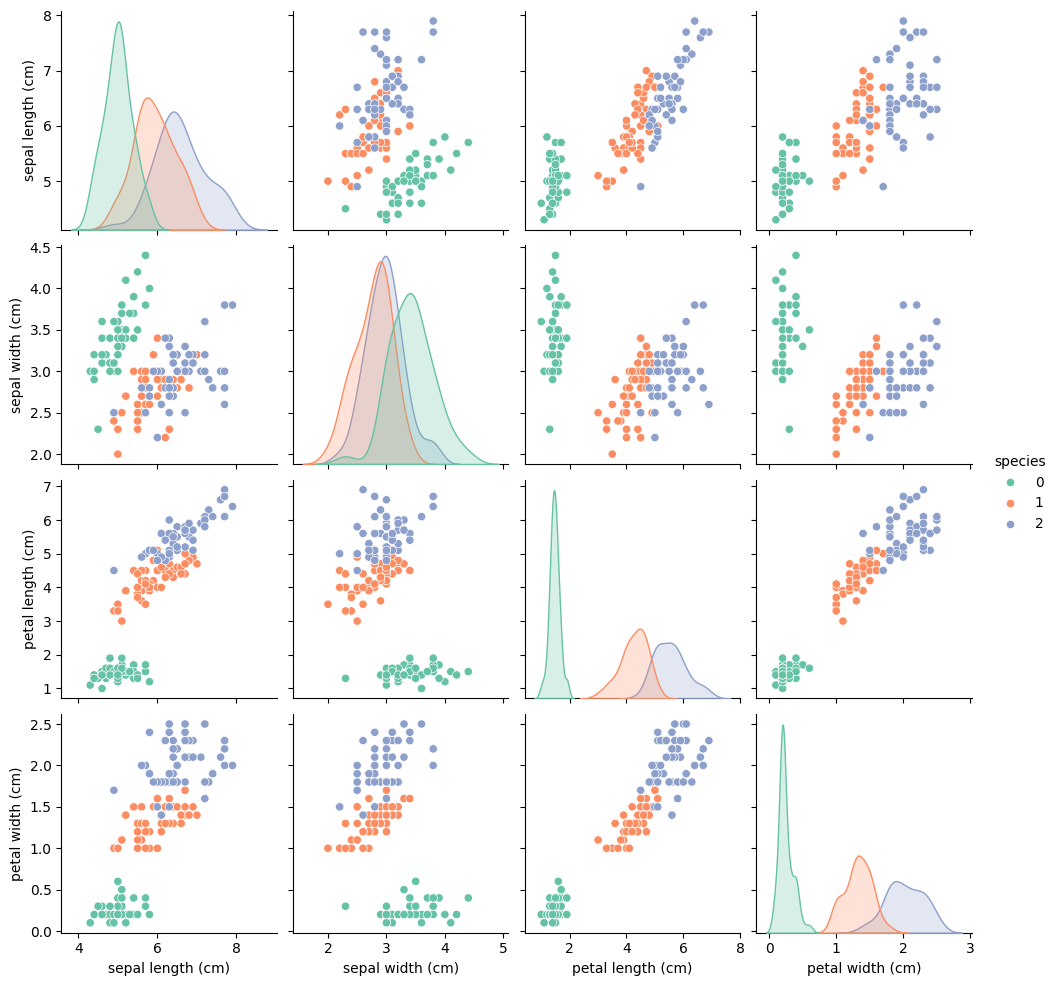

In [12]:
import seaborn as sns

# Pairplot to see feature separability
sns.pairplot(df, hue='species', palette='Set2')
plt.show()